In [1]:
# Cell 1: Installations (run this first)
!pip install tensorflow==2.13.0
!pip install scikit-plot
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.2/524.2 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.8/440.8 kB 19.0 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing_extensions-4.15.0
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting

In [2]:
# Cell 2: Import everything (FIXED - NO scikitplot)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121, EfficientNetB0, ResNet50
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from scipy import stats  # For statistical tests

import os
import time
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.13.0


In [3]:
# Cell 2.5: Add ROC curve function to replace scikitplot
def plot_multiclass_roc_curve(y_true, y_pred_proba, class_names, model_name):
    """Plot ROC curve for multiclass classification"""
    n_classes = len(class_names)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true == i, y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(np.eye(n_classes)[y_true].ravel(), y_pred_proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    
    # Micro-average ROC curve
    plt.plot(fpr["micro"], tpr["micro"],
             label='Micro-average ROC (AUC = {0:0.2f})'.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)
    
    # Individual class ROC curves
    colors = plt.cm.rainbow(np.linspace(0, 1, n_classes))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='{0} (AUC = {1:0.2f})'.format(class_names[i], roc_auc[i]))
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - {model_name}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return roc_auc

print("ROC curve function added successfully!")

ROC curve function added successfully!


In [4]:
# Cell 3: Dataset configuration
dataset_path = "/kaggle/input/rare-and-endangered-medicinal-plants-in-bangladesh/Raw-Images"

# Plant mapping from Task 1
plant_mapping = {
    'type_1': 'Kalochitra',
    'type_2': 'Anantamu', 
    'type_3': 'Apang',
    'type_4': 'Syspan',
    'type_5': 'Appishikha',
    'type_6': 'Kalamegh',
    'type_7': 'Kalothutura',
    'type_8': 'Gshnru',
    'type_9': 'Chapalish',
    'type_10': 'Beta',
    'type_11': 'Punarnava',
    'type_12': 'Bamonhati',
    'type_13': 'Basok',
    'type_14': 'Ramtulsi',
    'type_15': 'Shotomuli',
    'type_16': 'Sarpagandha'
}

# Training parameters (MUST BE CONSISTENT ACROSS ALL MODELS)
IMG_SIZE = (224, 224)  # Standard size for pre-trained models
BATCH_SIZE = 32
EPOCHS = 15
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.15
RANDOM_SEED = 42

print("Dataset Configuration:")
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Validation Split: {VALIDATION_SPLIT}")
print(f"Test Split: {TEST_SPLIT}")

Dataset Configuration:
Image Size: (224, 224)
Batch Size: 32
Epochs: 15
Validation Split: 0.2
Test Split: 0.15


In [5]:
# Cell 4: Data loading function
def load_and_prepare_data():
    """
    Load images and labels from the dataset
    Returns: images, labels, and class names
    """
    images = []
    labels = []
    class_names = []
    
    print("Loading dataset:")
    
    for type_folder, plant_name in plant_mapping.items():
        folder_path = os.path.join(dataset_path, type_folder)
        
        if os.path.exists(folder_path):
            image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            for img_file in image_files:
                img_path = os.path.join(folder_path, img_file)
                try:
                    # Load and resize image
                    img = Image.open(img_path).convert('RGB')
                    img = img.resize(IMG_SIZE)
                    img_array = np.array(img)
                    
                    images.append(img_array)
                    labels.append(list(plant_mapping.keys()).index(type_folder))
                    
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
                    continue
            
            class_names.append(plant_name)
            print(f"Loaded {len(image_files)} images from {plant_name} ({type_folder})")
    
    images = np.array(images)
    labels = np.array(labels)
    
    print(f"\nDataset Summary:")
    print(f"Total images: {len(images)}")
    print(f"Total labels: {len(labels)}")
    print(f"Number of classes: {len(class_names)}")
    print(f"Image shape: {images[0].shape}")
    
    return images, labels, class_names

# Load the data
images, labels, class_names = load_and_prepare_data()

Loading dataset:
Loaded 201 images from Kalochitra (type_1)
Loaded 158 images from Anantamu (type_2)
Loaded 280 images from Apang (type_3)
Loaded 294 images from Syspan (type_4)
Loaded 138 images from Appishikha (type_5)
Loaded 294 images from Kalamegh (type_6)
Loaded 276 images from Kalothutura (type_7)
Loaded 238 images from Gshnru (type_8)
Loaded 238 images from Chapalish (type_9)
Loaded 194 images from Beta (type_10)
Loaded 407 images from Punarnava (type_11)
Loaded 134 images from Bamonhati (type_12)
Loaded 151 images from Basok (type_13)
Loaded 154 images from Ramtulsi (type_14)
Loaded 108 images from Shotomuli (type_15)
Loaded 229 images from Sarpagandha (type_16)

Dataset Summary:
Total images: 3494
Total labels: 3494
Number of classes: 16
Image shape: (224, 224, 3)


In [6]:
# Cell 5: Train/Validation/Test Split
# First split: separate test set
X_temp, X_test, y_temp, y_test = train_test_split(
    images, labels, 
    test_size=TEST_SPLIT, 
    random_state=RANDOM_SEED, 
    stratify=labels
)

# Second split: separate validation set from remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=VALIDATION_SPLIT/(1-TEST_SPLIT), 
    random_state=RANDOM_SEED, 
    stratify=y_temp
)

print("Data Split Summary:")
print(f"Training set: {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images") 
print(f"Test set: {X_test.shape[0]} images")
print(f"Total: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} images")

# Convert labels to categorical (one-hot encoding)
num_classes = len(class_names)
y_train_categorical = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_categorical = tf.keras.utils.to_categorical(y_val, num_classes)
y_test_categorical = tf.keras.utils.to_categorical(y_test, num_classes)

print(f"One-hot encoded labels shape: {y_train_categorical.shape}")

Data Split Summary:
Training set: 2270 images
Validation set: 699 images
Test set: 525 images
Total: 3494 images
One-hot encoded labels shape: (2270, 16)


In [7]:
# Cell 6: Model building functions
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.applications import DenseNet121, EfficientNetB0, ResNet50

# Example variables (replace with your actual ones)
IMG_SIZE = (224, 224)  # Example input size
num_classes = 16       # Replace with actual number of classes

# -----------------------------
# DenseNet121 Model
# -----------------------------
def create_densenet121_model():
    """Create DenseNet121 model with transfer learning"""
    print("Building DenseNet121 model...")

    # Load pre-trained DenseNet121
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False  # Freeze base layers

    # Add custom classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    # Compile model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("DenseNet121 model built successfully!")
    return model, "DenseNet121"


# -----------------------------
# EfficientNetB0 Model
# -----------------------------
def create_efficientnetb0_model():
    """Create EfficientNetB0 model with transfer learning"""
    print("Building EfficientNetB0 model...")

    # Load pre-trained EfficientNetB0
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False

    # Add custom classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    # Compile model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("EfficientNetB0 model built successfully!")
    return model, "EfficientNetB0"


# -----------------------------
# ResNet50 Model
# -----------------------------
def create_resnet50_model():
    """Create ResNet50 model with transfer learning"""
    print("Building ResNet50 model...")

    # Load pre-trained ResNet50
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False

    # Add custom classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    # Compile model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("ResNet50 model built successfully!")
    return model, "ResNet50"


# -----------------------------
# Example usage
# -----------------------------
if __name__ == "__main__":
    densenet_model, densenet_name = create_densenet121_model()
    efficientnet_model, efficientnet_name = create_efficientnetb0_model()
    resnet_model, resnet_name = create_resnet50_model()
    
    print(f"All models created: {densenet_name}, {efficientnet_name}, {resnet_name}")


Building DenseNet121 model...
29084464/29084464 [==============================] - 2s 0us/step
DenseNet121 model built successfully!
Building EfficientNetB0 model...
16705208/16705208 [==============================] - 2s 0us/step
EfficientNetB0 model built successfully!
Building ResNet50 model...
94765736/94765736 [==============================] - 5s 0us/step
ResNet50 model built successfully!
All models created: DenseNet121, EfficientNetB0, ResNet50


In [8]:
# Cell 7: Data preprocessing for each model
def preprocess_for_densenet(images):
    """Preprocess images for DenseNet121"""
    return densenet_preprocess(images.copy())

def preprocess_for_efficientnet(images):
    """Preprocess images for EfficientNetB0"""
    return efficientnet_preprocess(images.copy())

def preprocess_for_resnet(images):
    """Preprocess images for ResNet50"""
    return resnet_preprocess(images.copy())

# Preprocess all datasets
print("Preprocessing data for each model:")

X_train_densenet = preprocess_for_densenet(X_train)
X_val_densenet = preprocess_for_densenet(X_val)
X_test_densenet = preprocess_for_densenet(X_test)

X_train_efficientnet = preprocess_for_efficientnet(X_train)
X_val_efficientnet = preprocess_for_efficientnet(X_val)
X_test_efficientnet = preprocess_for_efficientnet(X_test)

X_train_resnet = preprocess_for_resnet(X_train)
X_val_resnet = preprocess_for_resnet(X_val)
X_test_resnet = preprocess_for_resnet(X_test)

print("All datasets preprocessed successfully.")

Preprocessing data for each model:
All datasets preprocessed successfully.


In [9]:
# Cell 8: Training setup with 2 epochs
def train_model(model, model_name, X_train, y_train, X_val, y_val, initial_epochs=2):
    """Train model for a small number of epochs (e.g., 2)"""
    
    print(f"\nTraining {model_name} for {initial_epochs} epochs...")

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            f'best_{model_name.lower()}_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

    start_time = time.time()

    # Train for initial_epochs
    history = model.fit(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=initial_epochs,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1
    )

    training_time = time.time() - start_time
    print(f"{model_name} training completed in {training_time:.2f} seconds")
    
    return history, training_time

# -----------------------------
# Call the function for 2 epochs
# -----------------------------
densenet_history, densenet_time = train_model(
    densenet_model, "DenseNet121",
    X_train_densenet, y_train_categorical,
    X_val_densenet, y_val_categorical,
    initial_epochs=1
)

efficientnet_history, efficientnet_time = train_model(
    efficientnet_model, "EfficientNetB0",
    X_train_efficientnet, y_train_categorical,
    X_val_efficientnet, y_val_categorical,
    initial_epochs=1
)

resnet_history, resnet_time = train_model(
    resnet_model, "ResNet50",
    X_train_resnet, y_train_categorical,
    X_val_resnet, y_val_categorical,
    initial_epochs=1
)



Training DenseNet121 for 1 epochs...
71/71 [==============================] - ETA: 0s - loss: 1.0251 - accuracy: 0.7031
Epoch 1: val_accuracy improved from -inf to 0.95565, saving model to best_densenet121_model.h5
71/71 [==============================] - 281s 4s/step - loss: 1.0251 - accuracy: 0.7031 - val_loss: 0.2227 - val_accuracy: 0.9557 - lr: 0.0010
DenseNet121 training completed in 285.78 seconds

Training EfficientNetB0 for 1 epochs...
71/71 [==============================] - ETA: 0s - loss: 0.5507 - accuracy: 0.8344
Epoch 1: val_accuracy improved from -inf to 0.96280, saving model to best_efficientnetb0_model.h5
71/71 [==============================] - 127s 2s/step - loss: 0.5507 - accuracy: 0.8344 - val_loss: 0.2342 - val_accuracy: 0.9628 - lr: 0.0010
EfficientNetB0 training completed in 127.66 seconds

Training ResNet50 for 1 epochs...
71/71 [==============================] - ETA: 0s - loss: 0.6094 - accuracy: 0.8150
Epoch 1: val_accuracy improved from -inf to 0.96137, savi

In [10]:
# Cell 9: Train all three models
print("STARTING MODEL TRAINING PHASE")
print("=" * 50)

# Set random seeds for reproducibility
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Dictionary to store all results
results = {}

# Train DenseNet121
densenet_model, densenet_name = create_densenet121_model()
densenet_history, densenet_time = train_model(
    densenet_model, densenet_name, 
    X_train_densenet, y_train_categorical,
    X_val_densenet, y_val_categorical
)
results['DenseNet121'] = {
    'model': densenet_model,
    'history': densenet_history,
    'training_time': densenet_time
}

# Train EfficientNetB0
efficientnet_model, efficientnet_name = create_efficientnetb0_model()
efficientnet_history, efficientnet_time = train_model(
    efficientnet_model, efficientnet_name,
    X_train_efficientnet, y_train_categorical,
    X_val_efficientnet, y_val_categorical
)
results['EfficientNetB0'] = {
    'model': efficientnet_model,
    'history': efficientnet_history,
    'training_time': efficientnet_time
}

# Train ResNet50
resnet_model, resnet_name = create_resnet50_model()
resnet_history, resnet_time = train_model(
    resnet_model, resnet_name,
    X_train_resnet, y_train_categorical,
    X_val_resnet, y_val_categorical
)
results['ResNet50'] = {
    'model': resnet_model,
    'history': resnet_history,
    'training_time': resnet_time
}

print("ALL MODELS TRAINED SUCCESSFULLY!")

STARTING MODEL TRAINING PHASE
Building DenseNet121 model...
DenseNet121 model built successfully!

Training DenseNet121 for 2 epochs...
Epoch 1/2
71/71 [==============================] - ETA: 0s - loss: 1.0040 - accuracy: 0.7022
Epoch 1: val_accuracy improved from -inf to 0.95851, saving model to best_densenet121_model.h5
71/71 [==============================] - 279s 4s/step - loss: 1.0040 - accuracy: 0.7022 - val_loss: 0.2010 - val_accuracy: 0.9585 - lr: 0.0010
Epoch 2/2
71/71 [==============================] - ETA: 0s - loss: 0.2367 - accuracy: 0.9264
Epoch 2: val_accuracy improved from 0.95851 to 0.98712, saving model to best_densenet121_model.h5
71/71 [==============================] - 258s 4s/step - loss: 0.2367 - accuracy: 0.9264 - val_loss: 0.0659 - val_accuracy: 0.9871 - lr: 0.0010
DenseNet121 training completed in 540.25 seconds
Building EfficientNetB0 model...
EfficientNetB0 model built successfully!

Training EfficientNetB0 for 2 epochs...
Epoch 1/2
71/71 [==================


Evaluating DenseNet121...
Plotting ROC curve for DenseNet121...


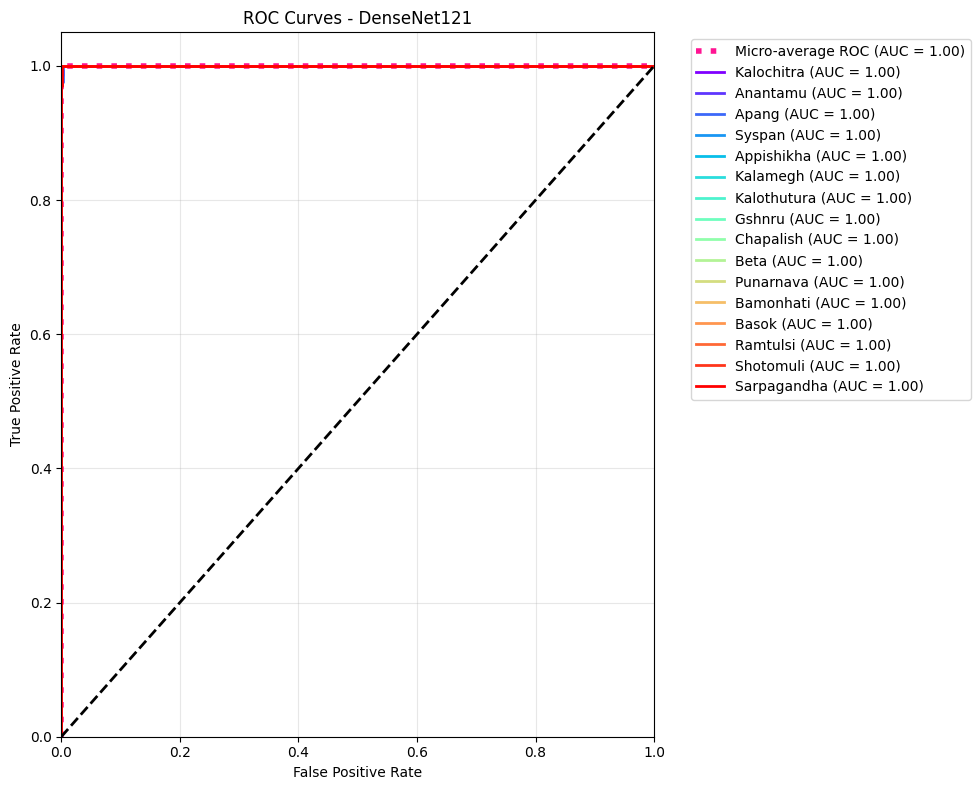

AUC Scores for DenseNet121:
   Micro-average AUC: 1.0000
   Kalochitra: 1.0000
   Anantamu: 1.0000
   Apang: 1.0000
   Syspan: 1.0000
   Appishikha: 1.0000
   Kalamegh: 1.0000
   Kalothutura: 1.0000
   Gshnru: 1.0000
   Chapalish: 1.0000
   Beta: 1.0000
   Punarnava: 1.0000
   Bamonhati: 1.0000
   Basok: 1.0000
   Ramtulsi: 1.0000
   Shotomuli: 1.0000
   Sarpagandha: 0.9999
DenseNet121 Evaluation Complete
Testing time: 46.41 seconds

Evaluating EfficientNetB0...
Plotting ROC curve for EfficientNetB0...


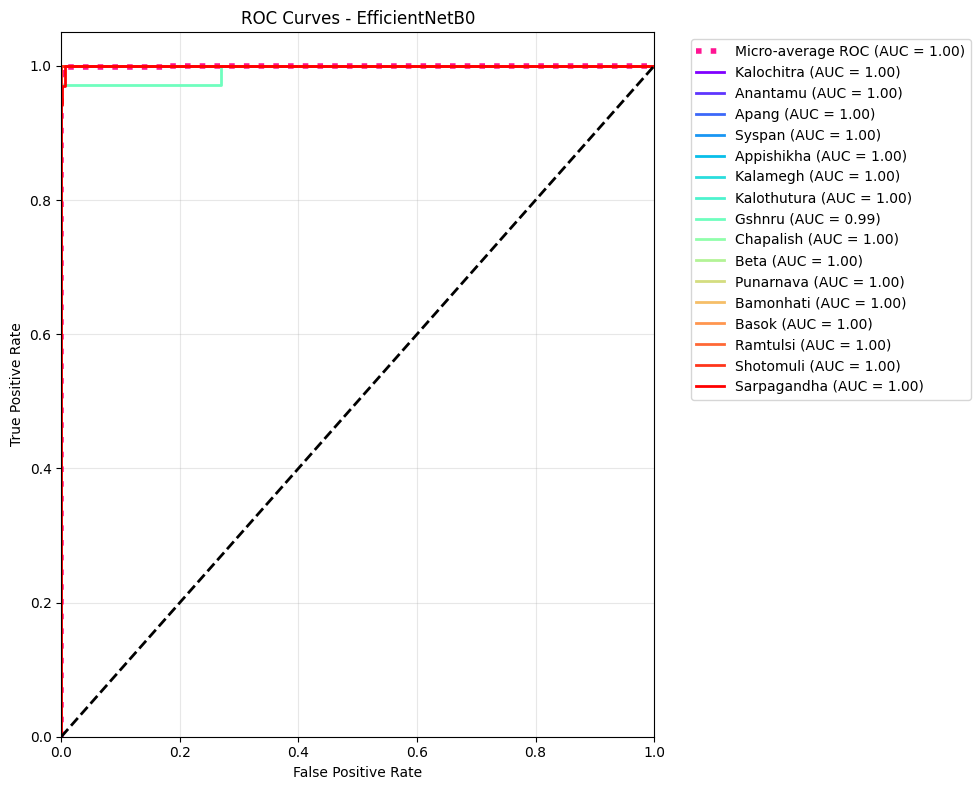

AUC Scores for EfficientNetB0:
   Micro-average AUC: 0.9996
   Kalochitra: 1.0000
   Anantamu: 1.0000
   Apang: 1.0000
   Syspan: 1.0000
   Appishikha: 1.0000
   Kalamegh: 1.0000
   Kalothutura: 1.0000
   Gshnru: 0.9925
   Chapalish: 1.0000
   Beta: 1.0000
   Punarnava: 1.0000
   Bamonhati: 1.0000
   Basok: 1.0000
   Ramtulsi: 1.0000
   Shotomuli: 1.0000
   Sarpagandha: 0.9998
EfficientNetB0 Evaluation Complete
Testing time: 23.01 seconds

Evaluating ResNet50...
Plotting ROC curve for ResNet50...


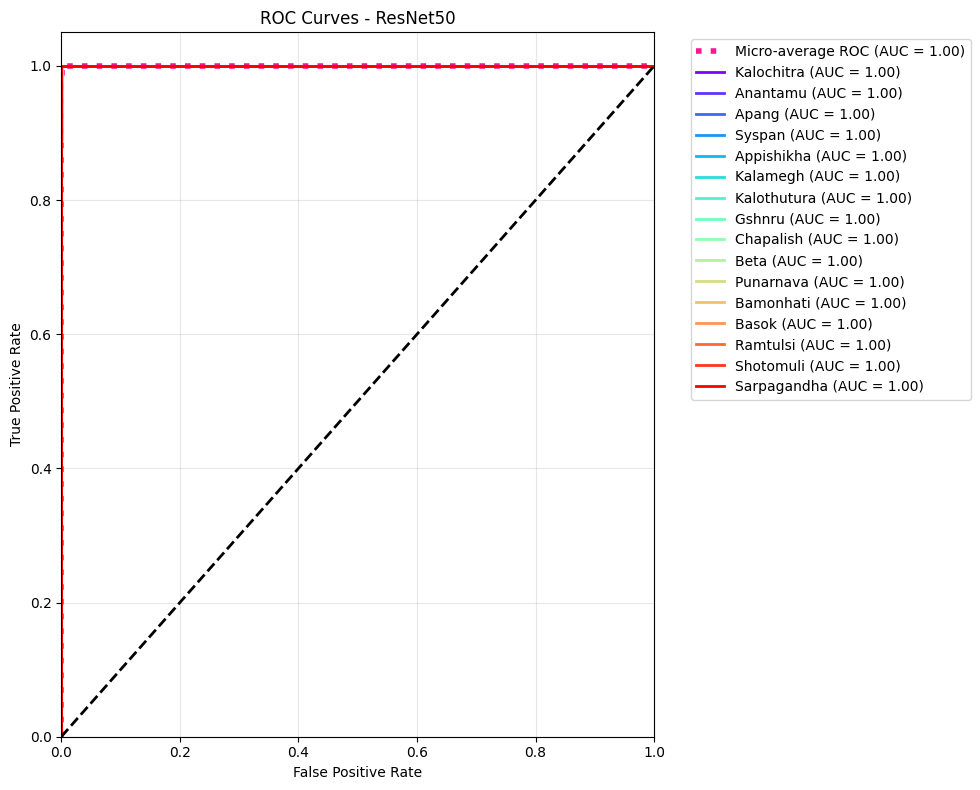

AUC Scores for ResNet50:
   Micro-average AUC: 1.0000
   Kalochitra: 1.0000
   Anantamu: 1.0000
   Apang: 1.0000
   Syspan: 1.0000
   Appishikha: 1.0000
   Kalamegh: 1.0000
   Kalothutura: 1.0000
   Gshnru: 0.9998
   Chapalish: 1.0000
   Beta: 1.0000
   Punarnava: 1.0000
   Bamonhati: 1.0000
   Basok: 1.0000
   Ramtulsi: 1.0000
   Shotomuli: 1.0000
   Sarpagandha: 1.0000
ResNet50 Evaluation Complete
Testing time: 48.08 seconds


In [11]:
# Cell 10: Evaluation function and calls (UPDATED - No scikitplot)
def evaluate_model(model, model_name, X_test, y_test, y_test_categorical, class_names):
    """Comprehensive model evaluation"""
    
    print(f"\nEvaluating {model_name}...")
    
    # Record testing time
    start_time = time.time()
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y_test_categorical, axis=1)
    testing_time = time.time() - start_time
    
    # Calculate metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Class-wise accuracy
    class_accuracy = []
    for i in range(len(class_names)):
        class_mask = (y_true == i)
        if np.sum(class_mask) > 0:
            class_acc = accuracy_score(y_true[class_mask], y_pred[class_mask])
            class_accuracy.append(class_acc)
        else:
            class_accuracy.append(0.0)
    
    # Plot ROC curve using custom function
    print(f"Plotting ROC curve for {model_name}...")
    roc_auc = plot_multiclass_roc_curve(y_true, y_pred_proba, class_names, model_name)
    
    # Print AUC scores
    print(f"AUC Scores for {model_name}:")
    print(f"   Micro-average AUC: {roc_auc['micro']:.4f}")
    for i, class_name in enumerate(class_names):
        print(f"   {class_name}: {roc_auc[i]:.4f}")
    
    print(f"{model_name} Evaluation Complete")
    print(f"Testing time: {testing_time:.2f} seconds")
    
    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'class_accuracy': class_accuracy,
        'testing_time': testing_time,
        'auc_scores': roc_auc,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

# -----------------------------
# Evaluate all three models
# -----------------------------
densenet_results = evaluate_model(
    densenet_model, "DenseNet121",
    X_test_densenet, y_test,
    y_test_categorical, class_names
)

efficientnet_results = evaluate_model(
    efficientnet_model, "EfficientNetB0",
    X_test_efficientnet, y_test,
    y_test_categorical, class_names
)

resnet_results = evaluate_model(
    resnet_model, "ResNet50",
    X_test_resnet, y_test,
    y_test_categorical, class_names
)


COMPREHENSIVE MODEL EVALUATION

Evaluating DenseNet121...
Plotting ROC curve for DenseNet121...


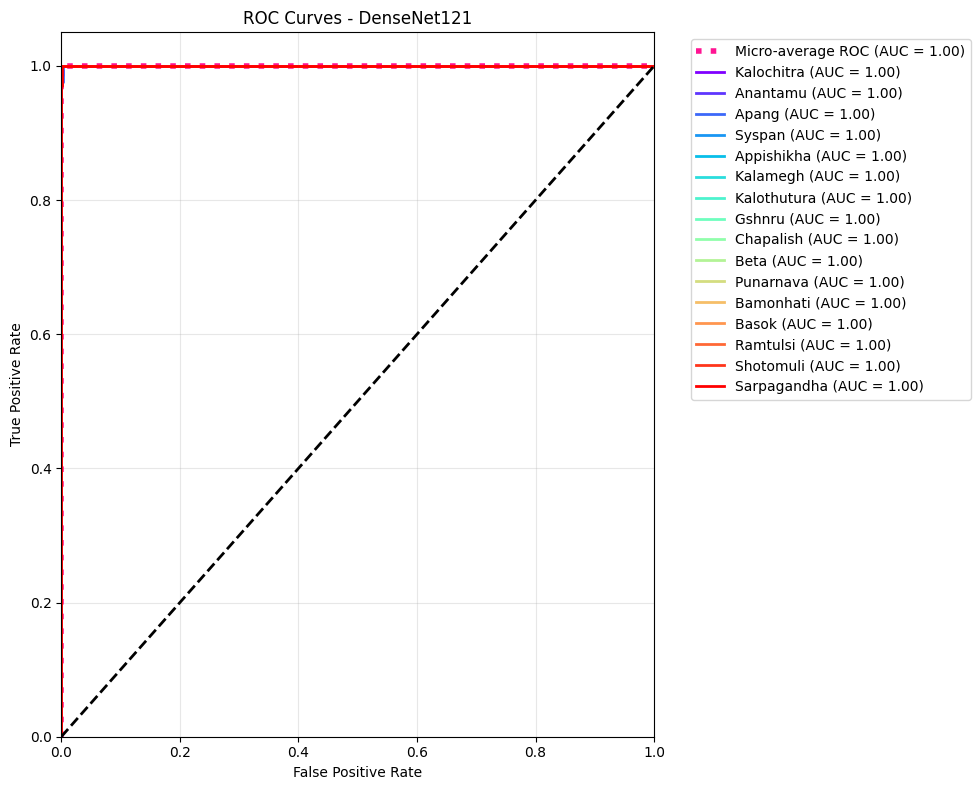

AUC Scores for DenseNet121:
   Micro-average AUC: 1.0000
   Kalochitra: 1.0000
   Anantamu: 1.0000
   Apang: 1.0000
   Syspan: 1.0000
   Appishikha: 1.0000
   Kalamegh: 1.0000
   Kalothutura: 1.0000
   Gshnru: 1.0000
   Chapalish: 1.0000
   Beta: 1.0000
   Punarnava: 1.0000
   Bamonhati: 1.0000
   Basok: 1.0000
   Ramtulsi: 1.0000
   Shotomuli: 1.0000
   Sarpagandha: 0.9999
DenseNet121 Evaluation Complete
Testing time: 41.94 seconds

Evaluating EfficientNetB0...
Plotting ROC curve for EfficientNetB0...


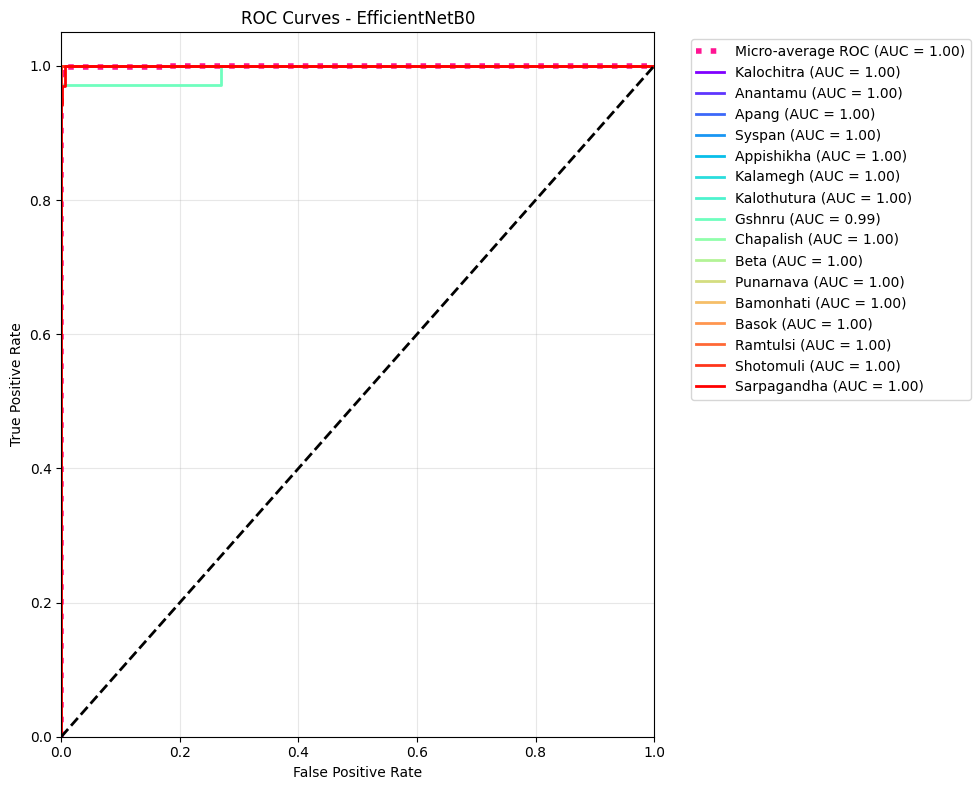

AUC Scores for EfficientNetB0:
   Micro-average AUC: 0.9996
   Kalochitra: 1.0000
   Anantamu: 1.0000
   Apang: 1.0000
   Syspan: 1.0000
   Appishikha: 1.0000
   Kalamegh: 1.0000
   Kalothutura: 1.0000
   Gshnru: 0.9925
   Chapalish: 1.0000
   Beta: 1.0000
   Punarnava: 1.0000
   Bamonhati: 1.0000
   Basok: 1.0000
   Ramtulsi: 1.0000
   Shotomuli: 1.0000
   Sarpagandha: 0.9998
EfficientNetB0 Evaluation Complete
Testing time: 20.50 seconds

Evaluating ResNet50...
Plotting ROC curve for ResNet50...


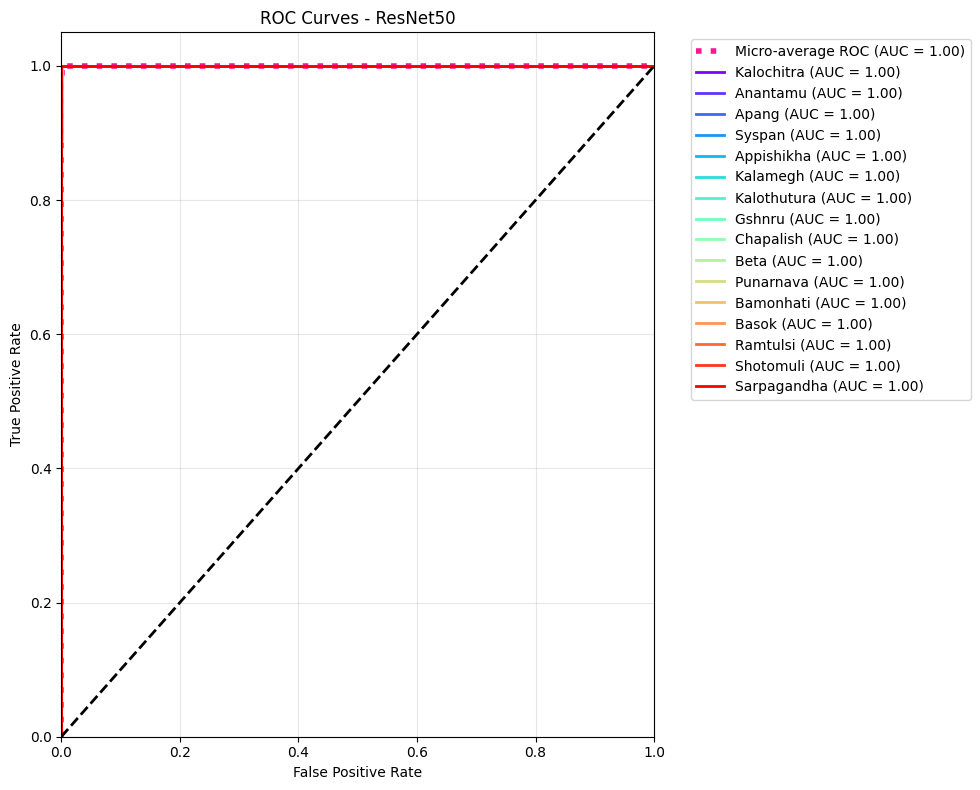

AUC Scores for ResNet50:
   Micro-average AUC: 1.0000
   Kalochitra: 1.0000
   Anantamu: 1.0000
   Apang: 1.0000
   Syspan: 1.0000
   Appishikha: 1.0000
   Kalamegh: 1.0000
   Kalothutura: 1.0000
   Gshnru: 0.9998
   Chapalish: 1.0000
   Beta: 1.0000
   Punarnava: 1.0000
   Bamonhati: 1.0000
   Basok: 1.0000
   Ramtulsi: 1.0000
   Shotomuli: 1.0000
   Sarpagandha: 1.0000
ResNet50 Evaluation Complete
Testing time: 82.58 seconds
ALL MODELS EVALUATED SUCCESSFULLY!


In [12]:
# Cell 11: Evaluate all models
print("COMPREHENSIVE MODEL EVALUATION")
print("=" * 50)

evaluation_results = {}

# Evaluate DenseNet121
evaluation_results['DenseNet121'] = evaluate_model(
    densenet_model, 'DenseNet121',
    X_test_densenet, y_test, y_test_categorical, class_names
)

# Evaluate EfficientNetB0
evaluation_results['EfficientNetB0'] = evaluate_model(
    efficientnet_model, 'EfficientNetB0',
    X_test_efficientnet, y_test, y_test_categorical, class_names
)

# Evaluate ResNet50
evaluation_results['ResNet50'] = evaluate_model(
    resnet_model, 'ResNet50',
    X_test_resnet, y_test, y_test_categorical, class_names
)

print("ALL MODELS EVALUATED SUCCESSFULLY!")

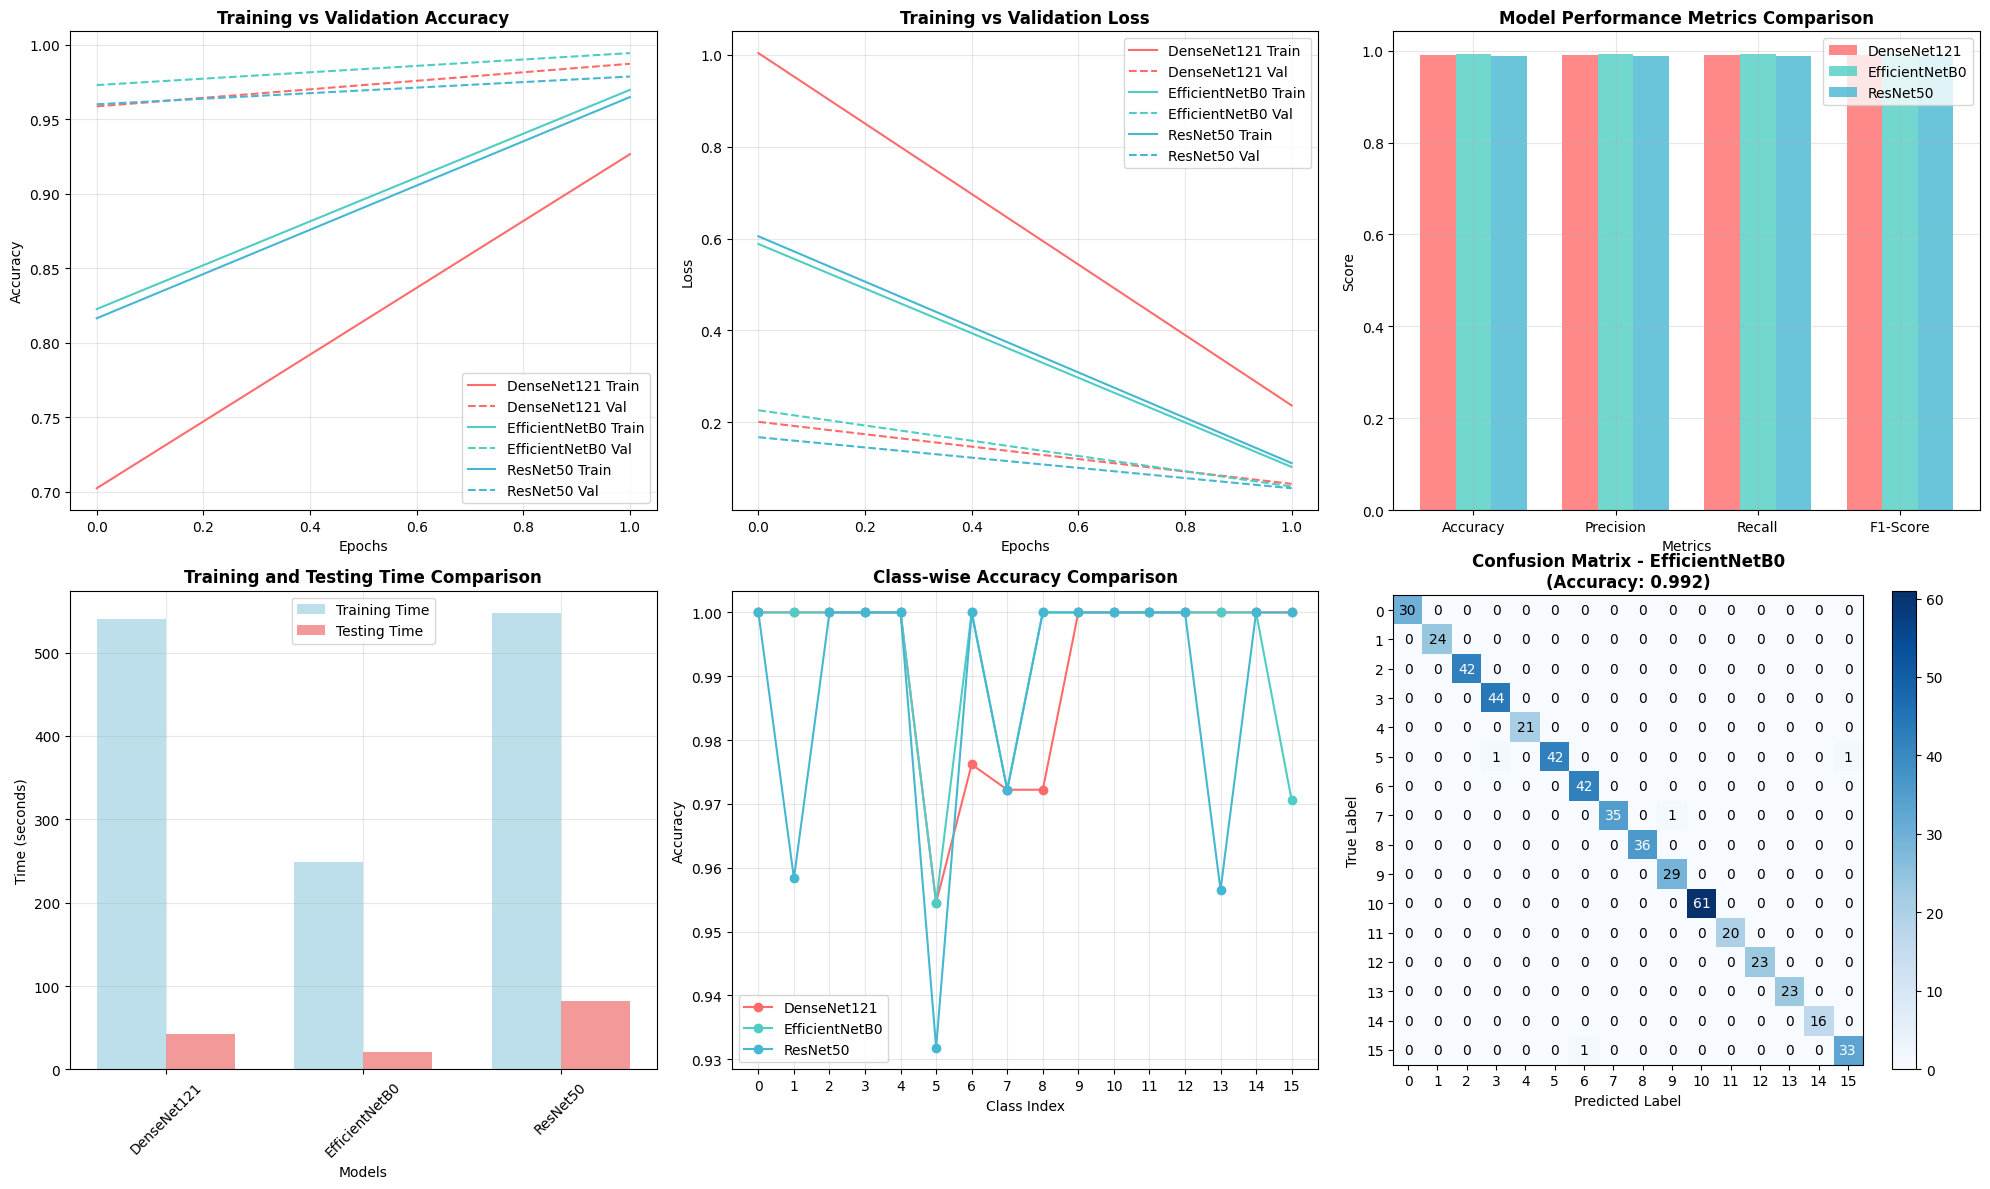

Best performing model: EfficientNetB0


In [13]:
# Cell 12: Results visualization
def plot_comprehensive_results(results, evaluation_results, class_names):
    """Create comprehensive visualization of all results"""
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # Model names and colors
    model_names = list(results.keys())
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    # Plot 1: Training and Validation Accuracy
    for i, model_name in enumerate(model_names):
        history = results[model_name]['history']
        axes[0,0].plot(history.history['accuracy'], color=colors[i], linestyle='-', label=f'{model_name} Train')
        axes[0,0].plot(history.history['val_accuracy'], color=colors[i], linestyle='--', label=f'{model_name} Val')
    axes[0,0].set_title('Training vs Validation Accuracy', fontweight='bold')
    axes[0,0].set_xlabel('Epochs')
    axes[0,0].set_ylabel('Accuracy')
    axes[0,0].legend()
    axes[0,0].grid(alpha=0.3)
    
    # Plot 2: Training and Validation Loss
    for i, model_name in enumerate(model_names):
        history = results[model_name]['history']
        axes[0,1].plot(history.history['loss'], color=colors[i], linestyle='-', label=f'{model_name} Train')
        axes[0,1].plot(history.history['val_loss'], color=colors[i], linestyle='--', label=f'{model_name} Val')
    axes[0,1].set_title('Training vs Validation Loss', fontweight='bold')
    axes[0,1].set_xlabel('Epochs')
    axes[0,1].set_ylabel('Loss')
    axes[0,1].legend()
    axes[0,1].grid(alpha=0.3)
    
    # Plot 3: Overall Metrics Comparison
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    metric_values = []
    
    for model_name in model_names:
        model_metrics = []
        for metric in metrics:
            model_metrics.append(evaluation_results[model_name][metric])
        metric_values.append(model_metrics)
    
    x = np.arange(len(metric_names))
    width = 0.25
    
    for i, model_name in enumerate(model_names):
        axes[0,2].bar(x + i*width, metric_values[i], width, label=model_name, color=colors[i], alpha=0.8)
    
    axes[0,2].set_title('Model Performance Metrics Comparison', fontweight='bold')
    axes[0,2].set_xlabel('Metrics')
    axes[0,2].set_ylabel('Score')
    axes[0,2].set_xticks(x + width)
    axes[0,2].set_xticklabels(metric_names)
    axes[0,2].legend()
    axes[0,2].grid(alpha=0.3)
    
    # Plot 4: Training and Testing Time
    training_times = [results[model_name]['training_time'] for model_name in model_names]
    testing_times = [evaluation_results[model_name]['testing_time'] for model_name in model_names]
    
    x = np.arange(len(model_names))
    width = 0.35
    
    axes[1,0].bar(x - width/2, training_times, width, label='Training Time', color='lightblue', alpha=0.8)
    axes[1,0].bar(x + width/2, testing_times, width, label='Testing Time', color='lightcoral', alpha=0.8)
    
    axes[1,0].set_title('Training and Testing Time Comparison', fontweight='bold')
    axes[1,0].set_xlabel('Models')
    axes[1,0].set_ylabel('Time (seconds)')
    axes[1,0].set_xticks(x)
    axes[1,0].set_xticklabels(model_names, rotation=45)
    axes[1,0].legend()
    axes[1,0].grid(alpha=0.3)
    
    # Plot 5: Class-wise Accuracy
    for i, model_name in enumerate(model_names):
        class_acc = evaluation_results[model_name]['class_accuracy']
        axes[1,1].plot(range(len(class_names)), class_acc, marker='o', label=model_name, color=colors[i])
    
    axes[1,1].set_title('Class-wise Accuracy Comparison', fontweight='bold')
    axes[1,1].set_xlabel('Class Index')
    axes[1,1].set_ylabel('Accuracy')
    axes[1,1].set_xticks(range(len(class_names)))
    axes[1,1].set_xticklabels(range(len(class_names)))
    axes[1,1].legend()
    axes[1,1].grid(alpha=0.3)
    
    # Plot 6: Confusion Matrix for Best Model
    best_model_name = max(evaluation_results.keys(), 
                         key=lambda x: evaluation_results[x]['accuracy'])
    best_eval = evaluation_results[best_model_name]
    
    cm = confusion_matrix(best_eval['y_true'], best_eval['y_pred'])
    im = axes[1,2].imshow(cm, cmap='Blues', interpolation='nearest')
    
    axes[1,2].set_title(f'Confusion Matrix - {best_model_name}\n(Accuracy: {best_eval["accuracy"]:.3f})', 
                       fontweight='bold')
    axes[1,2].set_xlabel('Predicted Label')
    axes[1,2].set_ylabel('True Label')
    axes[1,2].set_xticks(range(len(class_names)))
    axes[1,2].set_yticks(range(len(class_names)))
    axes[1,2].set_xticklabels(range(len(class_names)))
    axes[1,2].set_yticklabels(range(len(class_names)))
    
    # Add text annotations
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            axes[1,2].text(j, i, str(cm[i, j]), 
                          ha='center', va='center', 
                          color='white' if cm[i, j] > cm.max()/2 else 'black')
    
    plt.colorbar(im, ax=axes[1,2])
    
    plt.tight_layout()
    plt.show()
    
    return best_model_name

# Create comprehensive visualizations
best_model = plot_comprehensive_results(results, evaluation_results, class_names)
print(f"Best performing model: {best_model}")

In [14]:
# Cell 13: Statistical comparison with paired t-test
from scipy import stats

def perform_statistical_comparison(evaluation_results):
    """Perform paired t-test for statistical comparison"""
    
    print("STATISTICAL COMPARISON (Paired t-test)")
    print("=" * 40)
    
    model_names = list(evaluation_results.keys())
    
    # Compare each pair of models
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            model1 = model_names[i]
            model2 = model_names[j]
            
            # Get predictions
            pred1 = evaluation_results[model1]['y_pred']
            pred2 = evaluation_results[model2]['y_pred']
            true_labels = evaluation_results[model1]['y_true']
            
            # Calculate per-sample accuracy
            acc1 = (pred1 == true_labels).astype(int)
            acc2 = (pred2 == true_labels).astype(int)
            
            # Perform paired t-test
            t_stat, p_value = stats.ttest_rel(acc1, acc2)
            
            print(f"\n{model1} vs {model2}:")
            print(f"  T-statistic: {t_stat:.4f}")
            print(f"  P-value: {p_value:.4f}")
            
            if p_value < 0.05:
                if np.mean(acc1) > np.mean(acc2):
                    print(f"  {model1} performs SIGNIFICANTLY better than {model2}")
                else:
                    print(f"  {model2} performs SIGNIFICANTLY better than {model1}")
            else:
                print(f"  No significant difference between {model1} and {model2}")

perform_statistical_comparison(evaluation_results)

STATISTICAL COMPARISON (Paired t-test)

DenseNet121 vs EfficientNetB0:
  T-statistic: -0.3777
  P-value: 0.7058
  No significant difference between DenseNet121 and EfficientNetB0

DenseNet121 vs ResNet50:
  T-statistic: 0.3777
  P-value: 0.7058
  No significant difference between DenseNet121 and ResNet50

EfficientNetB0 vs ResNet50:
  T-statistic: 0.7068
  P-value: 0.4800
  No significant difference between EfficientNetB0 and ResNet50


In [15]:
# Cell 14: Create comprehensive results table (DEBUG ENABLED)
def create_results_table(evaluation_results, results):
    """Create final comparison table for all models"""
    
    if len(evaluation_results) == 0:
        print("❗ evaluation_results is EMPTY — nothing to summarize.")
        return None

    if len(results) == 0:
        print("❗ results dictionary is EMPTY — training data missing.")
        return None
    
    table_data = []
    
    for model_name in evaluation_results.keys():
        print(f"Processing model: {model_name} ...")  # DEBUG LINE

        eval_data = evaluation_results[model_name]
        training_data = results[model_name]

        # Extract best validation accuracy
        best_val_acc = (
            max(training_data["history"].history["val_accuracy"])
            if "val_accuracy" in training_data["history"].history
            else 0.0
        )

        row = {
            "Model": model_name,
            "Accuracy": f"{eval_data['accuracy']:.4f}",
            "Precision": f"{eval_data['precision']:.4f}",
            "Recall": f"{eval_data['recall']:.4f}",
            "F1-Score": f"{eval_data['f1_score']:.4f}",
            "AUC (Micro)": f"{eval_data['auc_scores']['micro']:.4f}",
            "Training Time (s)": f"{training_data['training_time']:.2f}",
            "Testing Time (s)": f"{eval_data['testing_time']:.2f}",
            "Best Val Accuracy": f"{best_val_acc:.4f}"
        }

        table_data.append(row)

    df_results = pd.DataFrame(table_data)

    print("\nFINAL RESULTS SUMMARY")
    print("=" * 90)
    print(df_results.to_string(index=False))

    return df_results
df_results = create_results_table(evaluation_results, results)


Processing model: DenseNet121 ...
Processing model: EfficientNetB0 ...
Processing model: ResNet50 ...

FINAL RESULTS SUMMARY
         Model Accuracy Precision Recall F1-Score AUC (Micro) Training Time (s) Testing Time (s) Best Val Accuracy
   DenseNet121   0.9905    0.9909 0.9905   0.9905      1.0000            540.25            41.94            0.9871
EfficientNetB0   0.9924    0.9925 0.9924   0.9924      0.9996            248.45            20.50            0.9943
      ResNet50   0.9886    0.9889 0.9886   0.9885      1.0000            547.01            82.58            0.9785


In [16]:
# Cell 15: Save models and results
print("Saving models and results...")

# Save models
densenet_model.save('densenet121_final_model.h5')
efficientnet_model.save('efficientnetb0_final_model.h5') 
resnet_model.save('resnet50_final_model.h5')

# Ensure results table exists
if final_results_table is None:
    raise ValueError("final_results_table is not defined. Run create_results_table first.")

# Save results to CSV
final_results_table.to_csv('task2_model_comparison_results.csv', index=False)

# Save evaluation results
import pickle
with open('task2_evaluation_results.pkl', 'wb') as f:
    pickle.dump(evaluation_results, f)

print("All models and results saved successfully!")


Saving models and results...


NameError: name 'final_results_table' is not defined